In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
with open ('air_pollution.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.head())

  ParentLocationCode SpatialDim      Dim1         Value  NumericValue  \
0                EMR        ARE  SEX_BTSX       7 [5-9]       7.26606   
1                AFR        ZMB  SEX_FMLE  266 [78-492]     266.23209   
2                WPR        AUS  SEX_BTSX       1 [0-1]       0.72083   
3                AFR        COG  SEX_FMLE  249 [43-528]     249.31205   
4                AMR        ATG  SEX_FMLE      5 [1-11]       4.77712   

                        Date IndicatorCode  
0  2022-08-26T09:40:54+02:00        AIR_10  
1  2022-08-26T09:41:03+02:00        AIR_10  
2  2022-08-26T09:40:54+02:00        AIR_10  
3  2022-08-26T09:40:55+02:00        AIR_10  
4  2022-08-26T09:40:54+02:00        AIR_10  


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 491076 entries, 0 to 491075
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ParentLocationCode  437864 non-null  str    
 1   SpatialDim          491076 non-null  str    
 2   Dim1                490882 non-null  str    
 3   Value               491076 non-null  str    
 4   NumericValue        490896 non-null  float64
 5   Date                491076 non-null  str    
 6   IndicatorCode       491076 non-null  str    
dtypes: float64(1), str(6)
memory usage: 26.2 MB


,NumericValue
count,4.908960e+05
mean,1.146485e+05
std,1.871427e+06
min,0.000000e+00
25%,7.391068e+00
50%,9.427950e+01
75%,1.735496e+03
max,2.110137e+08


In [4]:
df['NumericValue'].isnull().sum()

np.int64(180)

In [5]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

491076
490896
0


In [9]:
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)

['AIR_10', 'AIR_11', 'AIR_12', 'AIR_15', 'AIR_16', 'AIR_17', 'AIR_35', 'AIR_39', 'AIR_4', 'AIR_41', 'AIR_42', 'AIR_43', 'AIR_44', 'AIR_45', 'AIR_46', 'AIR_5', 'AIR_51', 'AIR_52', 'AIR_6', 'AIR_60', 'AIR_62', 'AIR_7', 'AIR_71', 'AIR_72', 'AIR_73', 'AIR_74', 'AIR_75', 'AIR_8', 'AIR_9', 'AIR_90', 'SDGAIRBOD', 'SDGAIRBODA', 'SDGPM25']


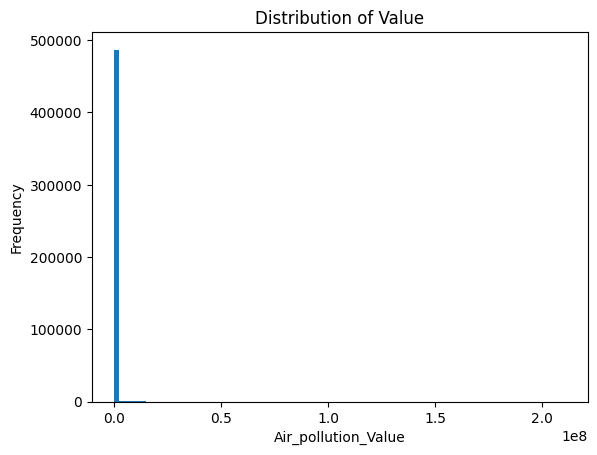

In [10]:
plt.figure()
plt.hist(df["NumericValue"], bins=100)
plt.xlabel("Air_pollution_Value")
plt.ylabel("Frequency")
plt.title("Distribution of Value")
plt.show()


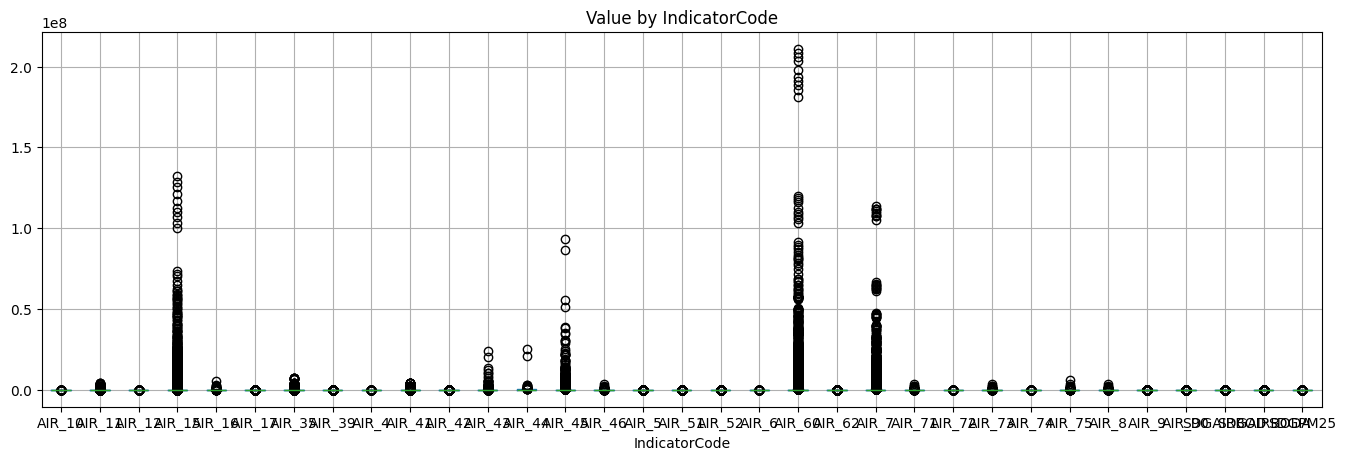

In [ ]:
fig, ax = plt.subplots(figsize=(16,5))
df.boxplot(column="NumericValue", by="IndicatorCode", ax=ax)

ax.set_title("Value by IndicatorCode")
plt.suptitle("")
plt.show()
